In [1]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import pylab as pl

In [2]:
dataframe=pd.read_csv("FuelConsumption.csv")
dataframe.head(10)

,MODELYEAR,MAKE,MODEL,VEHICLECLASS,ENGINESIZE,CYLINDERS,TRANSMISSION,FUELTYPE,FUELCONSUMPTION_CITY,FUELCONSUMPTION_HWY,FUELCONSUMPTION_COMB,FUELCONSUMPTION_COMB_MPG,CO2EMISSIONS
0,2014,ACURA,ILX,COMPACT,2.0,4,AS5,Z,9.9,6.7,8.5,33,196
1,2014,ACURA,ILX,COMPACT,2.4,4,M6,Z,11.2,7.7,9.6,29,221
2,2014,ACURA,ILX HYBRID,COMPACT,1.5,4,AV7,Z,6.0,5.8,5.9,48,136
3,2014,ACURA,MDX 4WD,SUV - SMALL,3.5,6,AS6,Z,12.7,9.1,11.1,25,255
4,2014,ACURA,RDX AWD,SUV - SMALL,3.5,6,AS6,Z,12.1,8.7,10.6,27,244
5,2014,ACURA,RLX,MID-SIZE,3.5,6,AS6,Z,11.9,7.7,10.0,28,230
6,2014,ACURA,TL,MID-SIZE,3.5,6,AS6,Z,11.8,8.1,10.1,28,232
7,2014,ACURA,TL AWD,MID-SIZE,3.7,6,AS6,Z,12.8,9.0,11.1,25,255
8,2014,ACURA,TL AWD,MID-SIZE,3.7,6,M6,Z,13.4,9.5,11.6,24,267
9,2014,ACURA,TSX,COMPACT,2.4,4,AS5,Z,10.6,7.5,9.2,31,212


In [9]:
clean_df=dataframe[["ENGINESIZE","CYLINDERS","FUELCONSUMPTION_COMB","CO2EMISSIONS"]]
clean_df.describe()

,ENGINESIZE,CYLINDERS,FUELCONSUMPTION_COMB,CO2EMISSIONS
count,1067.000000,1067.000000,1067.000000,1067.000000
mean,3.346298,5.794752,11.580881,256.228679
std,1.415895,1.797447,3.485595,63.372304
min,1.000000,3.000000,4.700000,108.000000
25%,2.000000,4.000000,9.000000,207.000000
50%,3.400000,6.000000,10.900000,251.000000
75%,4.300000,8.000000,13.350000,294.000000
max,8.400000,12.000000,25.800000,488.000000


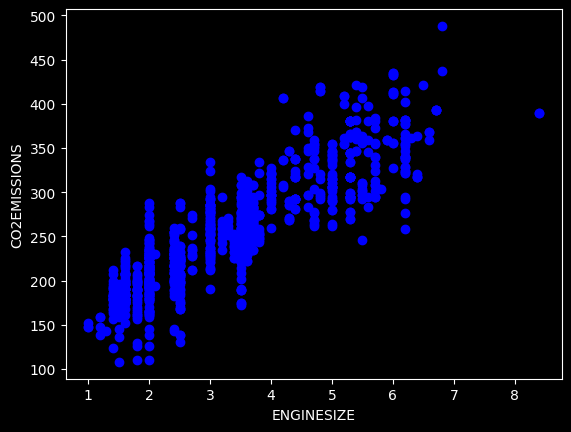

In [11]:
plt.plot(clean_df["ENGINESIZE"],clean_df["CO2EMISSIONS"],"bo")
plt.xlabel("ENGINESIZE")
plt.ylabel("CO2EMISSIONS")
plt.show()


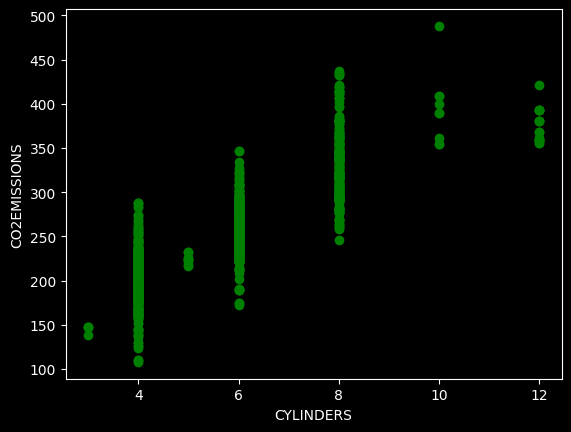

In [13]:
plt.plot(clean_df["CYLINDERS"],clean_df["CO2EMISSIONS"],"go")
plt.xlabel("CYLINDERS")
plt.ylabel("CO2EMISSIONS")
plt.show()

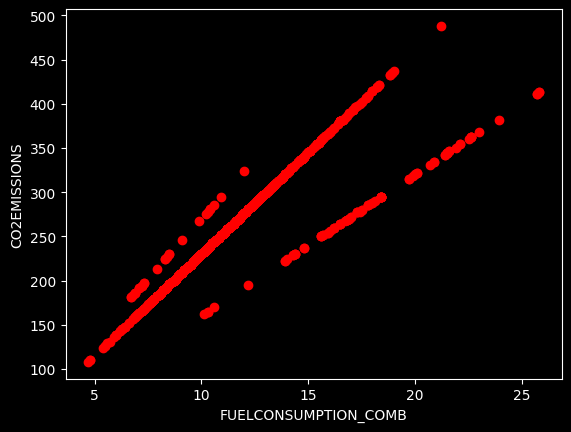

In [14]:
plt.plot(clean_df["FUELCONSUMPTION_COMB"],clean_df["CO2EMISSIONS"],"ro")
plt.xlabel("FUELCONSUMPTION_COMB")
plt.ylabel("CO2EMISSIONS")
plt.show()

In [15]:
msk=np.random.rand(len(dataframe))<0.8
train=clean_df[msk]
test=clean_df[~msk]

In [19]:
from sklearn import linear_model
from sklearn.preprocessing import PolynomialFeatures
regressor=linear_model.LinearRegression()
poly=PolynomialFeatures(degree=2)
trainx=np.asanyarray(train[["ENGINESIZE"]])
trainy=np.asanyarray(train[["CO2EMISSIONS"]])
poly2_x=poly.fit_transform(trainx)
regressor.fit(poly2_x,trainy)

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies a different convergence criterion for the `lsqr` solver.`tol` is set as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. This parameter has no effect when fittingon dense data... versionadded:: 1.7",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary ` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False


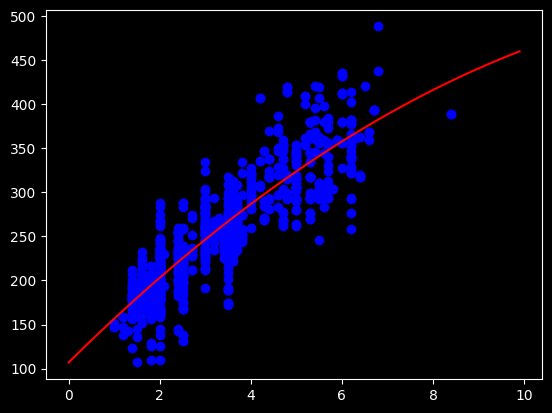

In [25]:
plt.scatter(clean_df["ENGINESIZE"],clean_df["CO2EMISSIONS"],color="blue")
xx=np.arange(0,10,0.1)
yy=regressor.intercept_[0]+regressor.coef_[0][1]*xx+regressor.coef_[0][2]*np.power(xx,2)
plt.plot(xx,yy,"r-")

In [21]:
from sklearn.metrics import mean_squared_error,r2_score
testx=np.asanyarray(test[["ENGINESIZE"]])
testy=np.asanyarray(test[["CO2EMISSIONS"]])
poly2_testx=poly.fit_transform(testx)
y_=regressor.predict(poly2_testx)
print("r2: %.2f"%r2_score(testy,y_))
print("mse: %.2f"%mean_squared_error(testy,y_))

r2: 0.76
mse: 910.92
